# Aula 7 - Fundamentos de Aprendizado Estatístico

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ry4n-felinto/impytech_2026/blob/main/aula_07/introdução_aprendizado.ipynb)

- **Professor:** Gustavo Sousa Cardoso
  - al.gustavo.cardoso@impatech.org.br

- **Monitores:**
  - Bianca Zavadisk
    - al.bianca.abreu@impatech.edu.br
  - Bruno Paula
    - al.bruno.paula@impatech.edu.br
  - Pedro Alberti
    - al.pedro.alberti@impatech.edu.br
  - Cristiane Sampaio
    - al.cristiane.sampaio@impatech.edu.br

- **Desenvolvedores:** 
  - Gustavo Sousa Cardoso
    - al.gustavo.cardoso@impatech.org.br

---

## 1 Introdução

Estaremos utilizando as bibliotecas `statsmodel`, `matplotlib`, `sklearn` e `numpy` para o seguinte notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

## O que é Aprendizado Estatístico?

Em termos gerais, assumimos que os dados seguem

$$Y = f(X) + \epsilon,$$

onde $f$ é a relação (desconhecida) entre as variáveis e $\epsilon$ é um ruído aleatório. Aprender estatisticamente é usar os dados para **estimar $f$**.

Há **dois objetivos** possíveis:

- **Inferência**: entender *como* $X$ afeta $Y$ (quais variáveis importam, com que efeito e com quanta confiança).
- **Predição** : prever o valor de $Y$ para $X$ ainda não vistos, mesmo que $f$ seja uma caixa-preta.

A forma mais simples de aprendizado são os **modelos paramétricos**: assumimos uma forma para $f$ (por exemplo, uma reta) e estimamos seus parâmetros. São **interpretáveis**, mas carregam o viés da suposição feita.

Para fins de ilustração, vamos gerar dados aleatórios com um dado formato e tentar ajustar duas regressões lineares.

# statsmodels

**Biblioteca de modelagem estatística e inferência.**

O `statsmodels` é voltado para **entender** os dados: além de ajustar modelos, ele
quantifica a incerteza de cada estimativa com erros-padrão, p-valores, intervalos de
confiança e testes de diagnóstico. Herda a tradição da estatística clássica e da
econometria (estilo R).

## Quando usar
Quando a pergunta é **"por quê?"** e **"quanto?"**, qual variável importa, qual o
tamanho e a direção do efeito, e com quanta confiança.

## Principais recursos
- **Regressão linear:** `OLS`, `WLS`, `GLS`
- **Modelos lineares generalizados:** `GLM` (logística, Poisson, ...)
- **Classificação:** `Logit`, `MNLogit`
- **Testes estatísticos:** teste t, F.

## Fluxo típico
```python
import statsmodels.api as sm

X = sm.add_constant(x)        # adiciona o intercepto (não é automático!)
modelo = sm.OLS(y, X).fit()   # define e ajusta
print(modelo.summary())       # relatório inferencial completo

Primeiramente vamos produzir dados com uma distribuição fixa apenas para ilustrar o ajuse acontecendo.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     873.3
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.61e-74
Time:                        15:08:46   Log-Likelihood:                -901.35
No. Observations:                 200   AIC:                             1807.
Df Residuals:                     198   BIC:                             1813.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3797      1.561      3.447      0.0

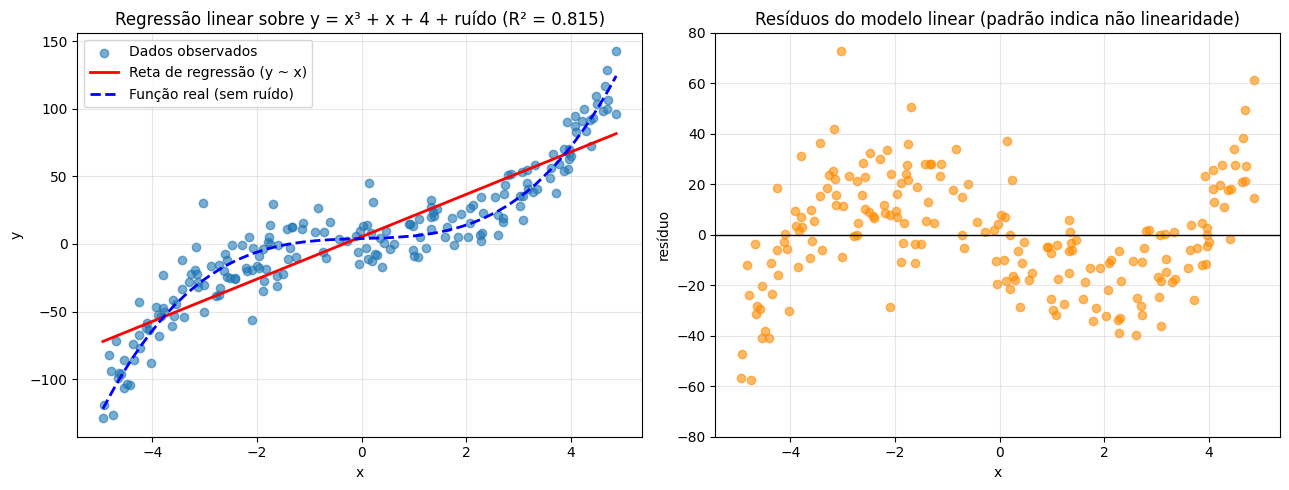

In [6]:
# Gera dados aleatórios seguindo y = x^3 + x + 4 + ruído
# Cada dado é a soma entre o valor dado pela fórmula e um ruído aleatório de média 0
# Numpy está sendo usado para operar nas matrizes com todos os dados de uma vez

np.random.seed(42)
n = 200
x = np.random.uniform(-5, 5, n)
ruido = np.random.normal(0, 15, n)
y = x**3 + x + 4 + ruido


# Ajusta um modelo de regressão linear simples (y ~ x) com statsmodels
# O statsmodel recebe a matriz x que contém os valores de x ( repare que isso é um vetor de apenas 1 dimensão)

X = sm.add_constant(x)
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

# Ordena os pontos para desenhar a reta ajustada corretamente
ordem = np.argsort(x)
x_ordenado = x[ordem]
y_pred = modelo.predict(X)[ordem]

# Função real (sem ruído) para comparação
y_real_ordenado = x_ordenado**3 + x_ordenado + 4

# Plota os dados observados, a reta ajustada e os resíduos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(x, y, alpha=0.6, label="Dados observados")
ax1.plot(x_ordenado, y_pred, color="red", linewidth=2, label="Reta de regressão (y ~ x)")
ax1.plot(x_ordenado, y_real_ordenado, color="blue", linewidth=2, linestyle="--", label="Função real (sem ruído)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title(f"Regressão linear sobre y = x³ + x + 4 + ruído (R² = {modelo.rsquared:.3f})")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.scatter(x, modelo.resid, alpha=0.6, color="darkorange")
ax2.axhline(0, color="black", linewidth=1)
ax2.set_ylim(-80, 80)
ax2.set_xlabel("x")
ax2.set_ylabel("resíduo")
ax2.set_title("Resíduos do modelo linear (padrão indica não linearidade)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2 Estatística - Teste de hipóteses, valor p e métricas

Ajustar o modelo é só o começo: precisamos avaliar *quão confiável* ele é. O `.summary()` do statsmodels traz esse ferramental de **inferência**. Os pontos principais:

- **Teste de hipóteses / valor p (`P>|t|`):** para cada coeficiente, testa-se a hipótese nula de que ele é **zero** (a variável não tem efeito). O valor p é a probabilidade de observar aquele coeficiente *caso ele fosse realmente zero* — **quanto menor, mais forte a evidência** de que a variável importa (convenção: significativo se $p < 0{,}05$).
- **R² e R² ajustado:** a fração da variação de $y$ que o modelo explica (0 = inútil, 1 = perfeito). O ajustado penaliza o número de preditores.
- **Estatística F (`Prob (F-statistic)`):** testa se **todos** os coeficientes são zero ao mesmo tempo, ou seja, se o modelo como um todo explica algo.

Vamos ler esses números, primeiro para o ajuste **linear** e depois para o **cúbico**:

In [3]:
import numpy as np
import statsmodels.api as sm

np.random.seed(42)
n = 200
x = np.random.uniform(-5, 5, n)
ruido = np.random.normal(0, 15, n)
y = x**3 + x + 4 + ruido

X = sm.add_constant(x)
modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.815
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     873.3
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.61e-74
Time:                        15:07:16   Log-Likelihood:                -901.35
No. Observations:                 200   AIC:                             1807.
Df Residuals:                     198   BIC:                             1813.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3797      1.561      3.447      0.0

In [4]:
X_cubico = sm.add_constant(np.column_stack([x, x**2, x**3]))
modelo_cubico = sm.OLS(y, X_cubico).fit()
print(modelo_cubico.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.920
Method:                 Least Squares   F-statistic:                     761.4
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          1.03e-107
Time:                        15:07:16   Log-Likelihood:                -816.38
No. Observations:                 200   AIC:                             1641.
Df Residuals:                     196   BIC:                             1654.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9920      1.599      2.497      0.0

### Comparando os ajustes e o risco de overfitting

Repare como o modelo **cúbico** tem R² bem maior que o **linear**, ele é flexível o bastante para capturar a curvatura de $x^3$. Note também que o coeficiente de $x^2$ costuma ter **valor p alto** (não significativo): correto, já que não existe termo quadrático na função geradora.

Mas aumentar a flexibilidade tem um preço: o **overfitting**. Um modelo flexível demais passa a ajustar o **ruído** em vez do sinal, vai muito bem no treino e mal em dados novos. Esse é o lado da alta variância na **decomposição viés-variância**:

$$E\left(y_0 - \hat{f}(x_0)\right)^2 = \operatorname{Var}(\hat{f}(x_0)) + \left[\operatorname{Bias}(\hat{f}(x_0))\right]^2 + \operatorname{Var}(\epsilon).$$

O erro total combina **viés** (modelo rígido demais → subajuste) e **variância** (modelo flexível demais → sobreajuste). A célula abaixo ilustra o overfitting ajustando polinômios de grau cada vez maior a dados gerados por $y = x^3 + x^2 + 3x$:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gera 100 amostras de y = x^2 + x^3 + 3x + ruído
np.random.seed(42)
n = 100
x = np.random.uniform(-3, 3, n)
ruido = np.random.normal(0, 5, n)
y = x**2 + x**3 + 3*x + ruido

# Grade fina para desenhar as curvas ajustadas de forma suave
x_grid = np.linspace(x.min(), x.max(), 500)
y_real = x_grid**2 + x_grid**3 + 3*x_grid  # função geradora, sem ruído

graus = [9, 15, 25]
fig, eixos = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, grau in zip(eixos, graus):
    # Polynomial.fit reescala x para [-1, 1] internamente -> estável em grau alto
    modelo = np.polynomial.Polynomial.fit(x, y, grau)
    y_ajuste = modelo(x_grid)

    ax.scatter(x, y, alpha=0.5, label="Dados (com ruído)")
    ax.plot(x_grid, y_real, color="blue", linewidth=2, linestyle="--", label="Função real")
    ax.plot(x_grid, y_ajuste, color="red", linewidth=2, label=f"Ajuste grau {grau}")
    ax.set_ylim(y.min() - 10, y.max() + 10)
    ax.set_xlabel("x")
    ax.set_title(f"Polinômio de grau {grau}")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

eixos[0].set_ylabel("y")
plt.tight_layout()
plt.show()

## 3 Problemas — Regressão × Classificação

Os problemas de aprendizado supervisionado se dividem em dois tipos:

- **Regressão:** a saída é um **valor** contínuo (foi o que fizemos acima).
- **Classificação:** a saída é uma **classe** (categoria).

Como os modelos trabalham com números, um problema de classificação é traduzido para *"qual a probabilidade desta entrada pertencer a cada classe?"*.

### Regressão Logística

A regressão linear "pura" não serve para probabilidade (não fica entre 0 e 1). A **regressão logística** resolve isso modelando o **log-odds** como uma combinação linear:

$$\log\left(\frac{p(X)}{1 - p(X)}\right) = \beta_0 + \beta_1 X.$$

Ajustando com `sm.Logit`, ganhamos o mesmo relatório inferencial de antes. E `exp(coeficiente)` dá a **razão de chances** (odds ratio): quanto aquela variável multiplica a chance do evento.

In [ ]:
# Gera dados binários: a classe y (0 ou 1) depende de x1 e x2
np.random.seed(42)
n = 300
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)

# log-odds (combinação linear) -> probabilidade -> sorteio de 0/1
z = 1.5 * x1 - 2.0 * x2 + 0.5
prob = 1 / (1 + np.exp(-z))
y = np.random.binomial(1, prob)

# Ajusta a regressão logística:  log(p / (1 - p)) = b0 + b1*x1 + b2*x2
X = sm.add_constant(np.column_stack([x1, x2]))
modelo_log = sm.Logit(y, X).fit()
print(modelo_log.summary())

# exp(coeficiente) = razão de chances (odds ratio) de cada variável
print("\nRazões de chance (odds ratios):")
print(np.exp(modelo_log.params))

## 4 Métodos

A partir dos moldes da regressão surgem muitos outros métodos. Antes deles, um conceito essencial de avaliação.

### Treino, teste e validação

Para medir a **capacidade de generalização** (e flagrar overfitting), separamos os dados em:

- **Treino** — o modelo usa para se ajustar;
- **Validação** — seleciona o melhor modelo e ajusta hiperparâmetros;
- **Teste** — avaliação final, imparcial.

Como primeira comparação, vamos gerar dados de classificação (4 distribuições normais + ruído) e confrontar um método **paramétrico** (regressão logística) com um **não-paramétrico** (**KNN**), usando `train_test_split`:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 4 distribuições normais 2D, cada uma com sua média (centro) e variância (espalhamento)
medias = [(-1, -2), (-1, -3), (1, 1), (2, 1)]
variancias = [0.8, 1.2, 1.0, 1.5]
n_por_classe = 30

X_list, y_list = [], []

# Amostra 30 pontos (x, y) de cada distribuição, rotulados de 0 a 3
for classe, ((mx, my), var) in enumerate(zip(medias, variancias)):
    px = np.random.normal(mx, np.sqrt(var), n_por_classe)
    py = np.random.normal(my, np.sqrt(var), n_por_classe)
    X_list.append(np.column_stack([px, py]))
    y_list.append(np.full(n_por_classe, classe))

# 20 pontos de ruído: espalhados uniformemente por toda a região, rótulo -1
ruido = np.random.uniform(-6, 6, size=(20, 2))
X_list.append(ruido)
y_list.append(np.full(20, -1))

X = np.vstack(X_list)   # (140, 2) -> coordenadas (x, y)
rotulos = np.concatenate(y_list)

# Visualiza as classes e o ruído
plt.figure(figsize=(7, 7))
for classe in range(4):
    pts = X[rotulos == classe]
    plt.scatter(pts[:, 0], pts[:, 1], alpha=0.7, label=f"Classe {classe}")
plt.scatter(X[rotulos == -1, 0], X[rotulos == -1, 1],
            c="gray", marker="x", alpha=0.7, label="Ruído")
plt.xlabel("x")
plt.ylabel("y")
plt.title("4 distribuições normais 2D + ruído (para classificação)")
plt.legend()
plt.grid(alpha=0.3)
plt.axis("equal")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap

# Usa X e rotulos gerados na célula anterior (4 classes + ruído rotulado como -1)
X_tr, X_te, y_tr, y_te = train_test_split(X, rotulos, test_size=0.3, random_state=42)

# Ajusta os dois classificadores
logreg = LogisticRegression(multi_class="multinomial", max_iter=1000).fit(X_tr, y_tr)
knn = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)

# Compara acurácia no conjunto de teste
acc_log = accuracy_score(y_te, logreg.predict(X_te))
acc_knn = accuracy_score(y_te, knn.predict(X_te))
print(f"Regressão logística — acurácia (teste): {acc_log:.3f}")
print(f"KNN (k=5)          — acurácia (teste): {acc_knn:.3f}")

# Monta uma grade para desenhar as fronteiras de decisão de cada modelo
h = 0.1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grade = np.c_[xx.ravel(), yy.ravel()]

cmap = ListedColormap(["#cccccc", "#8dd3c7", "#fb8072", "#80b1d3", "#fdb462"])

fig, eixos = plt.subplots(1, 2, figsize=(15, 6))
for ax, modelo, nome, acc in [
    (eixos[0], logreg, "Regressão logística (multinomial)", acc_log),
    (eixos[1], knn, "KNN (k=5)", acc_knn),
]:
    Z = modelo.predict(grade).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
    ax.scatter(X[:, 0], X[:, 1], c=rotulos, cmap=cmap, edgecolor="k", s=30)
    ax.set_title(f"{nome}\nacurácia = {acc:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

### Voltando à regressão: Regularização (Ridge e Lasso)

A regressão comum não tem viés, mas pode sofrer de **variância alta** quando há muitos preditores. A **regularização** introduz um viés controlado — penalizando os coeficientes — para reduzir a variância (de novo, o trade-off viés-variância).

Somamos ao RSS uma penalidade sobre os coeficientes:

- **Ridge (L2):** penaliza o **quadrado** — $RSS + \lambda \sum_j \beta_j^2$. Encolhe os coeficientes em direção a zero.
- **Lasso (L1):** penaliza o **módulo** — $RSS + \lambda \sum_j |\beta_j|$. Encolhe e ainda **zera** coeficientes irrelevantes (seleção de variáveis).

Abaixo, geramos dados em que só 2 de 8 preditores realmente importam e comparamos OLS, Ridge e Lasso:

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Dados: y depende só de x0 e x1, mas há 6 preditores irrelevantes (ruído)
np.random.seed(42)
n_amostras, p = 100, 8
X_reg = np.random.normal(0, 1, (n_amostras, p))
coef_reais = np.array([3.0, -2.0, 0, 0, 0, 0, 0, 0])   # só os 2 primeiros importam
y_reg = X_reg @ coef_reais + np.random.normal(0, 1, n_amostras)

# Ajusta 3 modelos: sem regularização, Ridge (L2) e Lasso (L1)
ols = LinearRegression().fit(X_reg, y_reg)
ridge = Ridge(alpha=10.0).fit(X_reg, y_reg)
lasso = Lasso(alpha=0.1).fit(X_reg, y_reg)

# Compara os coeficientes estimados por cada modelo
print(f"{'real':>8} {'OLS':>8} {'Ridge':>8} {'Lasso':>8}")
for j in range(p):
    print(f"{coef_reais[j]:>8.1f} {ols.coef_[j]:>8.3f} {ridge.coef_[j]:>8.3f} {lasso.coef_[j]:>8.3f}")

print("\nRepare: o Lasso zera os coeficientes irrelevantes (seleção de variáveis).")

### Outros métodos não-paramétricos e técnicas modernas

Além do KNN, há muitos outros métodos que **não supõem um formato fixo** para $f$ — mais flexíveis, porém menos interpretáveis e mais sensíveis a variações nos dados:

- **Árvores de Decisão** — sequência de perguntas sim/não; interpretáveis;
- **SVM** — separa as classes com a maior margem possível;
- **Random Forests** — combinam muitas árvores para reduzir a variância.

No extremo da flexibilidade estão as **Redes Neurais**: caixas-pretas de altíssima capacidade preditiva e baixa interpretabilidade — de volta ao trade-off **interpretabilidade × precisão**.

A biblioteca `scikit-learn` implementa todos esses métodos preditivos:

# scikit-learn (sklearn)
**Biblioteca de machine learning e predição.**
O `scikit-learn` é voltado para **prever**: o objetivo é acertar a resposta em dados
novos, ainda não vistos. Oferece um catálogo enorme de algoritmos sob uma interface
uniforme, além de todo o ferramental para treinar, validar e comparar modelos.
## Quando usar
Quando a pergunta é **"qual será o valor?"** — e o que importa é o desempenho
preditivo, mesmo que o modelo seja uma caixa-preta.
## Principais recursos
- **Modelos lineares:** `LinearRegression`, `LogisticRegression`
- **Métodos não-paramétricos:** `KNeighborsClassifier`, `DecisionTree`, `SVC`
- **Ensembles:** `RandomForest`, `GradientBoosting`
- **Ferramental:** `train_test_split`, validação cruzada, métricas, pipelines
- **Pré-processamento:** normalização, codificação, seleção de variáveis
## Fluxo típico
```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3)
modelo = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)
modelo.predict(X_te)          # prevê classes em dados novos